# Lab assignment №1, part 2

This lab assignment consists of several parts. You are supposed to make some transformations, train some models, estimate the quality of the models and explain your results.

Several comments:
* Don't hesitate to ask questions, it's a good practice.
* No private/public sharing, please. The copied assignments will be graded with 0 points.
* Blocks of this lab will be graded separately.

__*This is the second part of the assignment. First and third parts are waiting for you in the same directory.*__

## Part 2. Data preprocessing, model training and evaluation.

### 1. Reading the data
Today we work with the [dataset](https://archive.ics.uci.edu/ml/datasets/Statlog+%28Vehicle+Silhouettes%29), describing different cars for multiclass ($k=4$) classification problem. The data is available below.

In [1]:
# If on colab, uncomment the following lines

# ! wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_made/homeworks/lab01_ml_pipeline/car_data.csv

In [42]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm

dataset = pd.read_csv('car_data.csv', delimiter=',', header=None).values
data = dataset[:, :-1].astype(int)
target = dataset[:, -1]

print(data.shape, target.shape)

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.35)
# y_train = y_train.reshape(y_train.shape[0], 1)
# y_test = y_test.reshape(y_test.shape[0], 1)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(846, 19) (846,)
(549, 19) (549,) (297, 19) (297,)


To get some insights about the dataset, `pandas` might be used. The `train` part is transformed to `pd.DataFrame` below.

In [39]:
X_train_pd = pd.DataFrame(X_train)

# First 15 rows of our dataset.
X_train_pd.head(15)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,502,86,36,66,128,57,8,131,52,18,127,148,252,139,76,5,27,183,187
1,39,81,45,68,169,73,6,151,44,19,146,173,336,186,75,7,0,183,189
2,417,96,36,74,183,70,6,149,43,19,127,178,341,127,69,0,17,201,205
3,801,84,38,60,128,56,5,132,50,18,130,148,261,141,75,8,4,185,188
4,839,90,44,72,157,64,8,137,48,18,144,159,283,171,65,9,4,196,203
5,825,86,39,84,149,57,8,156,43,20,133,185,358,157,74,0,23,183,190
6,620,108,56,103,234,73,10,221,30,25,174,232,718,214,73,8,3,187,197
7,138,88,37,63,130,58,5,125,54,18,130,141,230,145,74,14,20,184,188
8,257,92,43,69,158,56,7,149,44,19,143,170,333,168,63,14,18,198,203
9,261,91,39,88,189,63,9,175,38,21,132,197,457,156,69,0,23,191,198


Methods `describe` and `info` deliver some useful information.

In [3]:
X_train_pd.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
count,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000
mean,414.020036,93.837887,44.834244,82.291439,169.045537,61.539162,8.535519,169.204007,40.901639,20.612022,148.054645,189.021858,442.306011,174.380692,72.435337,6.316940,12.907104,188.979964,195.608379
std,245.893013,8.216346,6.218338,15.892739,33.988240,7.802583,4.493823,33.848610,7.962353,2.628577,14.669744,32.079388,180.369302,32.912387,7.246816,4.960216,9.014208,6.211124,7.519658
min,0.000000,77.000000,33.000000,40.000000,109.000000,47.000000,2.000000,112.000000,26.000000,17.000000,118.000000,130.000000,184.000000,112.000000,59.000000,0.000000,0.000000,176.000000,181.000000
25%,195.000000,87.000000,40.000000,70.000000,140.000000,57.000000,7.000000,146.000000,33.000000,19.000000,137.000000,167.000000,318.000000,150.000000,67.000000,2.000000,6.000000,184.000000,190.000000
50%,419.000000,93.000000,44.000000,80.000000,168.000000,61.000000,8.000000,157.000000,43.000000,20.000000,146.000000,179.000000,364.000000,172.000000,72.000000,6.000000,11.000000,188.000000,196.000000
75%,633.000000,100.000000,50.000000,98.000000,196.000000,65.000000,10.000000,200.000000,46.000000,23.000000,160.000000,217.000000,600.000000,197.000000,76.000000,9.000000,19.000000,193.000000,201.000000
max,845.000000,119.000000,59.000000,112.000000,333.000000,138.000000,55.000000,262.000000,61.000000,28.000000,188.000000,320.000000,998.000000,268.000000,135.000000,22.000000,41.000000,206.000000,211.000000


In [4]:
X_train_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549 entries, 0 to 548
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       549 non-null    int32
 1   1       549 non-null    int32
 2   2       549 non-null    int32
 3   3       549 non-null    int32
 4   4       549 non-null    int32
 5   5       549 non-null    int32
 6   6       549 non-null    int32
 7   7       549 non-null    int32
 8   8       549 non-null    int32
 9   9       549 non-null    int32
 10  10      549 non-null    int32
 11  11      549 non-null    int32
 12  12      549 non-null    int32
 13  13      549 non-null    int32
 14  14      549 non-null    int32
 15  15      549 non-null    int32
 16  16      549 non-null    int32
 17  17      549 non-null    int32
 18  18      549 non-null    int32
dtypes: int32(19)
memory usage: 40.9 KB


In [28]:
y_train

array(['opel', 'saab', 'bus', 'opel', 'saab', 'opel', 'van', 'van', 'van',
       'saab', 'van', 'saab', 'bus', 'saab', 'bus', 'saab', 'van', 'saab',
       'opel', 'van', 'bus', 'bus', 'saab', 'bus', 'van', 'van', 'opel',
       'saab', 'van', 'bus', 'van', 'bus', 'van', 'bus', 'bus', 'saab',
       'van', 'opel', 'van', 'saab', 'bus', 'saab', 'van', 'bus', 'opel',
       'saab', 'opel', 'saab', 'saab', 'bus', 'saab', 'opel', 'van',
       'opel', 'opel', 'opel', 'saab', 'van', 'opel', 'opel', 'van',
       'van', 'bus', 'saab', 'saab', 'bus', 'van', 'bus', 'opel', 'opel',
       'bus', 'opel', 'saab', 'van', 'opel', 'bus', 'saab', 'saab', 'van',
       'saab', 'saab', 'opel', 'van', 'bus', 'van', 'saab', 'bus', 'van',
       'opel', 'saab', 'opel', 'saab', 'opel', 'bus', 'bus', 'opel',
       'saab', 'van', 'opel', 'saab', 'opel', 'bus', 'bus', 'saab', 'bus',
       'van', 'bus', 'opel', 'saab', 'van', 'opel', 'bus', 'opel', 'van',
       'opel', 'saab', 'van', 'bus', 'van', 'opel', 

### 2. Machine Learning pipeline
Here you are supposed to perform the desired transformations. Please, explain your results briefly after each task.

#### 2.0. Data preprocessing
* Make some transformations of the dataset (if necessary). Briefly explain the transformations

In [4]:
### YOUR CODE HERE
# I don't see any missing values, so my idea is to scale all values

from sklearn.preprocessing import StandardScaler
"""
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

X_train"""

array([[ 0.77159386,  1.16741088,  1.86164854, ...,  1.06403897,
        -0.13437839,  0.06939861],
       [ 1.45890357,  1.52902941,  1.37051685, ...,  0.48953327,
        -0.62950412, -1.5634515 ],
       [-1.31502905, -0.15852373, -1.0851416 , ..., -0.8892804 ,
         0.19570543, -0.20274308],
       ...,
       [-1.62370107,  1.04687137,  0.06083234, ..., -0.65947812,
         1.02091498, -0.33881392],
       [-0.39724422,  1.52902941,  0.71567459, ...,  0.25973099,
         2.17620835,  1.83831956],
       [-0.99812576,  1.04687137,  1.53422741, ...,  1.52364352,
         0.03066352,  0.61368198]])

In [17]:
# Target consists of 4 classes, so it would be better to perform one hot encoding
"""
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
ohe.fit(y_train)
y_train = ohe.transform(y_train)
y_test = ohe.transform(y_test)

y_train"""

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 549 stored elements and shape (549, 4)>

In [24]:
y_train

array([['bus'],
       ['saab'],
       ['opel'],
       ['saab'],
       ['saab'],
       ['saab'],
       ['van'],
       ['saab'],
       ['bus'],
       ['saab'],
       ['saab'],
       ['van'],
       ['van'],
       ['van'],
       ['bus'],
       ['bus'],
       ['bus'],
       ['opel'],
       ['saab'],
       ['opel'],
       ['saab'],
       ['saab'],
       ['saab'],
       ['bus'],
       ['saab'],
       ['saab'],
       ['van'],
       ['van'],
       ['saab'],
       ['saab'],
       ['bus'],
       ['bus'],
       ['saab'],
       ['van'],
       ['saab'],
       ['opel'],
       ['opel'],
       ['saab'],
       ['van'],
       ['saab'],
       ['saab'],
       ['saab'],
       ['opel'],
       ['bus'],
       ['van'],
       ['bus'],
       ['opel'],
       ['bus'],
       ['van'],
       ['opel'],
       ['saab'],
       ['van'],
       ['van'],
       ['van'],
       ['saab'],
       ['opel'],
       ['bus'],
       ['opel'],
       ['bus'],
       ['saab'],
      

#### 2.1. Basic logistic regression
* Find optimal hyperparameters for logistic regression with cross-validation on the `train` data (small grid/random search is enough, no need to find the *best* parameters).

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression: `multi_class='multinomial'`, `solver='saga'` `tol=1e-3` and ` max_iter=500`.*

In [ ]:
### YOUR CODE HERE

In [46]:
# You might use this command to install scikit-plot. 
# Warning, if you a running locally, don't call pip from within jupyter, call it from terminal in the corresponding 
# virtual environment instead

# ! pip install scikit-plot
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

lr = LogisticRegression(solver='saga', max_iter=500, tol=1e-3)
scaler = StandardScaler()
pipeline = Pipeline([('scaler', scaler), ('lr', lr)])
gs_lr = GridSearchCV(pipeline, param_grid={'lr__C': [0.01, 0.1, 1, 10, 100, 1000], 'lr__penalty': ['l1', 'l2']}, cv=5)
gs_lr.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('lr',
                                        LogisticRegression(max_iter=500,
                                                           solver='saga',
                                                           tol=0.001))]),
             param_grid={'lr__C': [0.01, 0.1, 1, 10, 100, 1000],
                         'lr__penalty': ['l1', 'l2']})

In [47]:
gs_lr.best_score_

0.7795663052543788

In [52]:
temp = gs_lr.best_params_

temp

{'lr__C': 10, 'lr__penalty': 'l2'}

In [56]:
pipeline = Pipeline([('scaler', scaler), ('lr', lr)])
pipeline.set_params(**temp)
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred, average='macro'))

0.835016835016835
0.8312616686205206


In [57]:
predicted_proba = pipeline.predict_proba(X_test)
predicted_proba

array([[2.80271711e-02, 6.36376894e-01, 3.35590969e-01, 4.96541464e-06],
       [9.83787846e-01, 5.84855786e-03, 4.79802383e-03, 5.56557225e-03],
       [7.64172934e-03, 2.21700370e-01, 7.70654689e-01, 3.21149783e-06],
       ...,
       [4.66397168e-02, 4.24324259e-01, 5.28989602e-01, 4.64215048e-05],
       [9.92940362e-01, 3.95449940e-03, 3.10482773e-03, 3.10864575e-07],
       [9.64988830e-02, 4.73191951e-01, 4.30272653e-01, 3.65131491e-05]])

In [46]:
y_pred

array(['van', 'van', 'opel', 'bus', 'bus', 'saab', 'bus', 'opel', 'bus',
       'opel', 'saab', 'saab', 'van', 'bus', 'van', 'opel', 'bus', 'opel',
       'van', 'opel', 'saab', 'opel', 'van', 'bus', 'saab', 'saab',
       'saab', 'van', 'opel', 'saab', 'van', 'van', 'van', 'bus', 'van',
       'van', 'saab', 'van', 'van', 'saab', 'opel', 'opel', 'opel', 'bus',
       'van', 'saab', 'saab', 'van', 'opel', 'van', 'saab', 'van', 'opel',
       'saab', 'van', 'bus', 'opel', 'bus', 'saab', 'opel', 'van', 'saab',
       'bus', 'saab', 'bus', 'van', 'saab', 'bus', 'van', 'saab', 'saab',
       'van', 'opel', 'saab', 'opel', 'bus', 'opel', 'bus', 'saab',
       'saab', 'saab', 'opel', 'bus', 'bus', 'van', 'bus', 'van', 'bus',
       'opel', 'opel', 'saab', 'van', 'bus', 'opel', 'van', 'opel',
       'opel', 'bus', 'saab', 'saab', 'van', 'saab', 'opel', 'bus',
       'saab', 'saab', 'saab', 'van', 'saab', 'opel', 'opel', 'saab',
       'saab', 'van', 'saab', 'van', 'opel', 'saab', 'van', 'van'

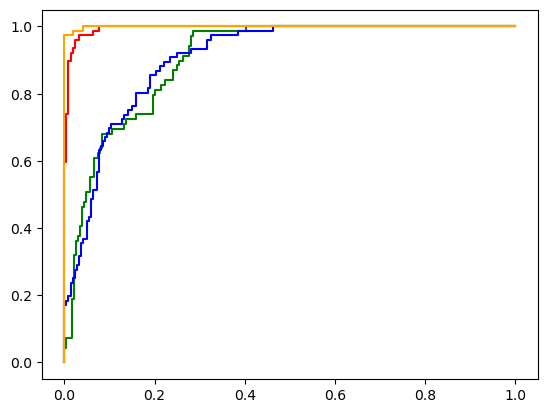

In [58]:
from sklearn.metrics import roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt

names = ["bus", "opel" ,"saab", "van"]
colors = ["red", "green", "blue", "orange"]
for i, name in enumerate(names):
    y_test_curr = y_test == name
    y_probs = predicted_proba[:, i]
    fpr, tpr, thresholds = roc_curve(y_test_curr, y_probs)
    plt.plot(fpr, tpr, label=name, color=colors[i])
plt.show()

#### 2.2. PCA: explained variance plot
* Apply the PCA to the train part of the data. Build the explaided variance plot. 

In [61]:
### YOUR CODE HERE
from sklearn.decomposition import PCA

pca = PCA()
std = StandardScaler()
pca.fit(std.fit_transform(X_train))

print(pca.explained_variance_ratio_, len(pca.explained_variance_ratio_))

[5.01216737e-01 1.61374256e-01 9.76676524e-02 6.10663282e-02
 5.13855383e-02 4.75567970e-02 2.78895737e-02 1.81952937e-02
 1.13743436e-02 8.05596176e-03 4.43228164e-03 3.04024995e-03
 2.10560988e-03 1.81063044e-03 1.03882211e-03 8.11180316e-04
 6.40984962e-04 3.20367086e-04 1.73925416e-05] 19


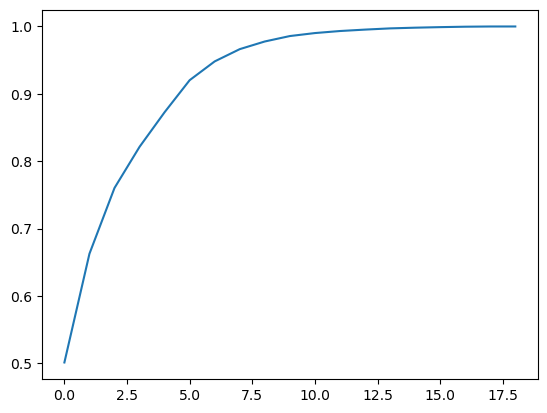

In [62]:
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)
plt.plot(cumulative_variance_ratio)
plt.show()

#### 2.3. PCA trasformation
* Select the appropriate number of components. Briefly explain your choice. Should you normalize the data?

*Use `fit` and `transform` methods to transform the `train` and `test` parts.*

In [87]:
### YOUR CODE HERE
pca = PCA(n_components=12)

**Note: From this point `sklearn` [Pipeline](https://scikit-learn.org/stable/modules/compose.html) might be useful to perform transformations on the data. Refer to the [docs](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) for more information.**

#### 2.4. Logistic regression on PCA-preprocessed data.
* Find optimal hyperparameters for logistic regression with cross-validation on the transformed by PCA `train` data.

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression: `multi_class='multinomial'`, `solver='saga'` and `tol=1e-3`*

In [88]:
### YOUR CODE HERE
from sklearn.pipeline import Pipeline

lr_pca = LogisticRegression(solver='saga', max_iter=500, tol=1e-3)
pipeline = Pipeline([('scaler', scaler), ('pca', pca), ('lr', lr_pca)])
gs_lr_pca = GridSearchCV(pipeline, param_grid={'lr__C': [0.01, 0.1, 1, 10, 100, 1000], 'lr__penalty': ['l1', 'l2']})
gs_lr_pca.fit(X_train, y_train)

GridSearchCV(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=12)),
                                       ('lr',
                                        LogisticRegression(max_iter=500,
                                                           solver='saga',
                                                           tol=0.001))]),
             param_grid={'lr__C': [0.01, 0.1, 1, 10, 100, 1000],
                         'lr__penalty': ['l1', 'l2']})

In [89]:
lr_bp = gs_lr_pca.best_params_
lr_bp

{'lr__C': 1, 'lr__penalty': 'l2'}

In [90]:
pipeline.set_params(**lr_bp)
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred, average='macro'))

0.7508417508417509
0.745622350839178


#### 2.5. Decision tree
* Now train a desicion tree on the same data. Find optimal tree depth (`max_depth`) using cross-validation.

* Measure the model quality using the same metrics you used above.

In [91]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
pipeline = Pipeline([('scaler', scaler), ('dtc', dtc)])
param_grid = {'dtc__max_depth': [i for i in range(1, 1000, 10)]}
gs_dt = GridSearchCV(pipeline, param_grid=param_grid)
gs_dt.fit(X_train, y_train)
dt_bp = gs_dt.best_params_
print(dt_bp)


pipeline.set_params(**dt_bp)
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred, average='macro'))
# YOUR CODE HERE

{'dtc__max_depth': 831}
0.734006734006734
0.7252889001418363


0.6531986531986532
0.6641043553964543


#### 2.6. Bagging.
Here starts the ensembling part.

First we will use the __Bagging__ approach. Build an ensemble of $N$ algorithms varying N from $N_{min}=2$ to $N_{max}=100$ (with step 5).

We will build two ensembles: of logistic regressions and of decision trees.

*Comment: each ensemble should be constructed from models of the same family, so logistic regressions should not be mixed up with decision trees.*


*Hint 1: To build a __Bagging__ ensebmle varying the ensemble size efficiently you might generate $N_{max}$ subsets of `train` data (of the same size as the original dataset) using bootstrap procedure once. Then you train a new instance of logistic regression/decision tree with optimal hyperparameters you estimated before on each subset (so you train it from scratch). Finally, to get an ensemble of $N$ models you average the $N$ out of $N_{max}$ models predictions.*

*Hint 2: sklearn might help you with this taks. Some appropriate function/class might be out there.*

* Plot `f1` and `accuracy` scores plots w.r.t. the size of the ensemble.

* Briefly analyse the plot. What is the optimal number of algorithms? Explain your answer.

* How do you think, are the hyperparameters for the decision trees you found in 2.5 optimal for trees used in ensemble? 

In [ ]:
# YOUR CODE HERE

 10%|█         | 2/20 [00:00<00:03,  4.62it/s]C:\Users\vav11\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\vav11\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\vav11\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
 15%|█▌        | 3/20 [00:01<00:07,  2.28it/s]C:\Users\vav11\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\vav11\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\vav11\ana

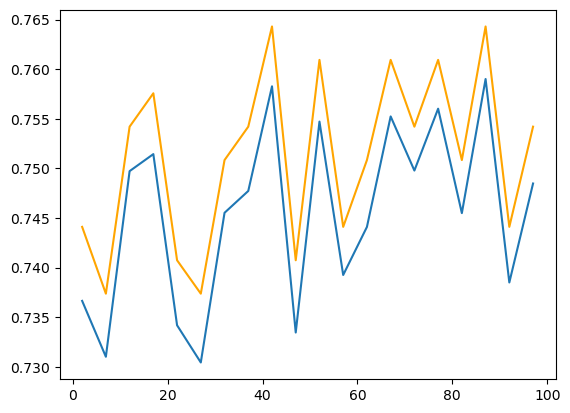

In [92]:
from sklearn.ensemble import BaggingClassifier
from tqdm import tqdm

acc = np.zeros((100 - 2) // 5 + 1)
f1 = np.zeros((100 - 2) // 5 + 1)

for i in tqdm(range(2, 100, 5)):
    bclr = BaggingClassifier(estimator=lr_pca, n_estimators=i)
    pipeline = Pipeline([('scaler', scaler), ('pca', pca), ('bclr', bclr)])
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    acc[i//5] = accuracy_score(y_test, y_pred)
    f1[i//5] = f1_score(y_test, y_pred, average='macro')

plt.plot(range(2, 100, 5), acc, label='ACC', color="orange")
plt.plot(range(2, 100, 5), f1, label='F1')
plt.show()
# YOUR CODE HERE

100%|██████████| 20/20 [00:06<00:00,  3.13it/s]


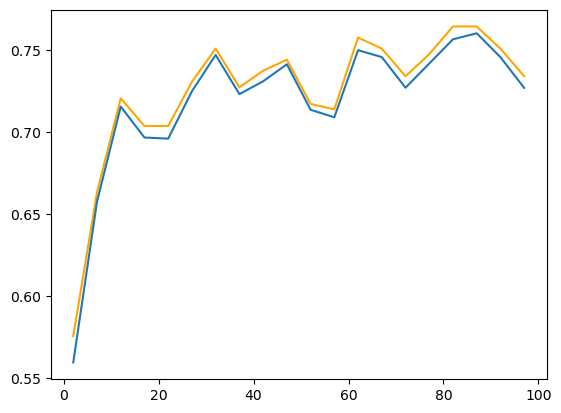

In [93]:
acc = np.zeros((100 - 2) // 5 + 1)
f1 = np.zeros((100 - 2) // 5 + 1)

for i in tqdm(range(2, 100, 5)):
    bcdt = BaggingClassifier(estimator=dtc, n_estimators=i)
    pipeline = Pipeline([('scaler', scaler), ('pca', pca), ('bcdt', bcdt)])
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    acc[i//5] = accuracy_score(y_test, y_pred)
    f1[i//5] = f1_score(y_test, y_pred, average='macro')

plt.plot(range(2, 100, 5), acc, label='ACC', color="orange")
plt.plot(range(2, 100, 5), f1, label='F1')
plt.show()

#### 2.7. Random Forest
Now we will work with the Random Forest (its `sklearn` implementation).

* * Plot `f1` and `accuracy` scores plots w.r.t. the number of trees in Random Forest.

* What is the optimal number of trees you've got? Is it different from the optimal number of logistic regressions/decision trees in 2.6? Explain the results briefly.

100%|██████████| 20/20 [00:02<00:00,  9.59it/s]


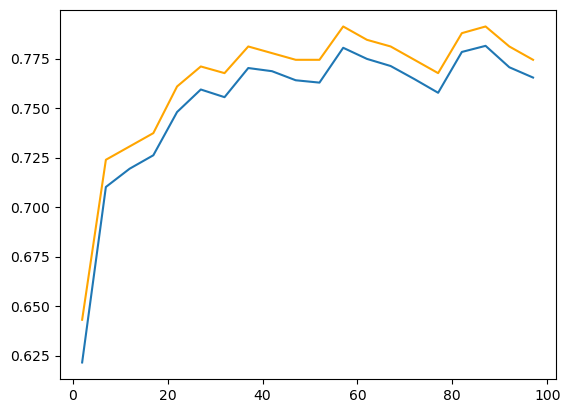

In [94]:
from sklearn.ensemble import RandomForestClassifier

acc = np.zeros((100 - 2) // 5 + 1)
f1 = np.zeros((100 - 2) // 5 + 1)

for i in tqdm(range(2, 100, 5)):
    rfc = RandomForestClassifier(n_estimators=i)
    pipeline = Pipeline([('scaler', scaler), ('rf', rfc)])
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    acc[i//5] = accuracy_score(y_test, y_pred)
    f1[i//5] = f1_score(y_test, y_pred, average='macro')

plt.plot(range(2, 100, 5), acc, label='ACC', color="orange")
plt.plot(range(2, 100, 5), f1, label='F1')
plt.show()
# YOUR CODE HERE

In [95]:
param_grid = {'rf__n_estimators': [i for i in range(2, 100, 5)]}

gs_rfc = GridSearchCV(pipeline, param_grid=param_grid)
gs_rfc.fit(X_train, y_train)

rfc_bp = gs_rfc.best_params_

In [96]:
rfc_bp

{'rf__n_estimators': 27}

#### 2.8. Learning curve
Your goal is to estimate, how does the model behaviour change with the increase of the `train` dataset size.

* Split the training data into 10 equal (almost) parts. Then train the models from above (Logistic regression, Desicion Tree, Random Forest) with optimal hyperparameters you have selected on 1 part, 2 parts (combined, so the train size in increased by 2 times), 3 parts and so on.

* Build a plot of `accuracy` and `f1` scores on `test` part, varying the `train` dataset size (so the axes will be score - dataset size.

* Analyse the final plot. Can you make any conlusions using it? 

In [99]:
# YOUR CODE HERE
per_one_i = X_train.shape[0] // 10
acc = np.zeros((10, 3))
f1 = np.zeros((10, 3))
x = np.array(range(per_one_i, X_train.shape[0], per_one_i))
for i in tqdm(range(10)):
    X_curr = X_train[:(i+1)*per_one_i]
    y_curr = y_train[:(i+1)*per_one_i]
    lr = LogisticRegression(solver='saga', max_iter=500, tol=1e-3)
    dt = DecisionTreeClassifier()
    rfc = RandomForestClassifier()
    pip1 = Pipeline([('scaler', scaler), ('pca', pca), ('lr', lr)])
    pip2 = Pipeline([('scaler', scaler), ('dtc', dt)])
    pip3 = Pipeline([('scaler', scaler), ('rf', rfc)])
    pip1.set_params(**lr_bp)
    pip2.set_params(**dt_bp)
    pip3.set_params(**rfc_bp)
    pip1.fit(X_curr, y_curr)
    pip2.fit(X_curr, y_curr)
    pip3.fit(X_curr, y_curr)
    lr_pred = pip1.predict(X_test)
    dt_pred = pip2.predict(X_test)
    rfc_pred = pip3.predict(X_test)
    acc[i][0] = accuracy_score(y_test, lr_pred)
    acc[i][1] = accuracy_score(y_test, dt_pred)
    acc[i][2] = accuracy_score(y_test, rfc_pred)
    f1[i][0] = f1_score(y_test, lr_pred, average='macro')
    f1[i][1] = f1_score(y_test, dt_pred, average='macro')
    f1[i][2] = f1_score(y_test, rfc_pred, average='macro')


100%|██████████| 10/10 [00:01<00:00,  9.51it/s]


In [100]:
acc, f1, x

(array([[0.71043771, 0.60942761, 0.65656566],
        [0.71380471, 0.54208754, 0.71380471],
        [0.70707071, 0.5993266 , 0.73737374],
        [0.75420875, 0.68013468, 0.8047138 ],
        [0.76767677, 0.68350168, 0.78451178],
        [0.73063973, 0.70707071, 0.78114478],
        [0.73400673, 0.73400673, 0.80808081],
        [0.75084175, 0.72053872, 0.76767677],
        [0.75084175, 0.65656566, 0.78451178],
        [0.75420875, 0.74074074, 0.77104377]]),
 array([[0.69409524, 0.61146687, 0.63045039],
        [0.7114045 , 0.53805115, 0.69891252],
        [0.70075758, 0.5976427 , 0.72398351],
        [0.75137909, 0.67625444, 0.79772696],
        [0.76325034, 0.68330113, 0.77455249],
        [0.72441036, 0.69637337, 0.77077304],
        [0.72905472, 0.72584271, 0.79804205],
        [0.74581638, 0.71665455, 0.75603901],
        [0.74691889, 0.66090313, 0.77564481],
        [0.74907987, 0.73486126, 0.76028794]]),
 array([ 54, 108, 162, 216, 270, 324, 378, 432, 486, 540]))

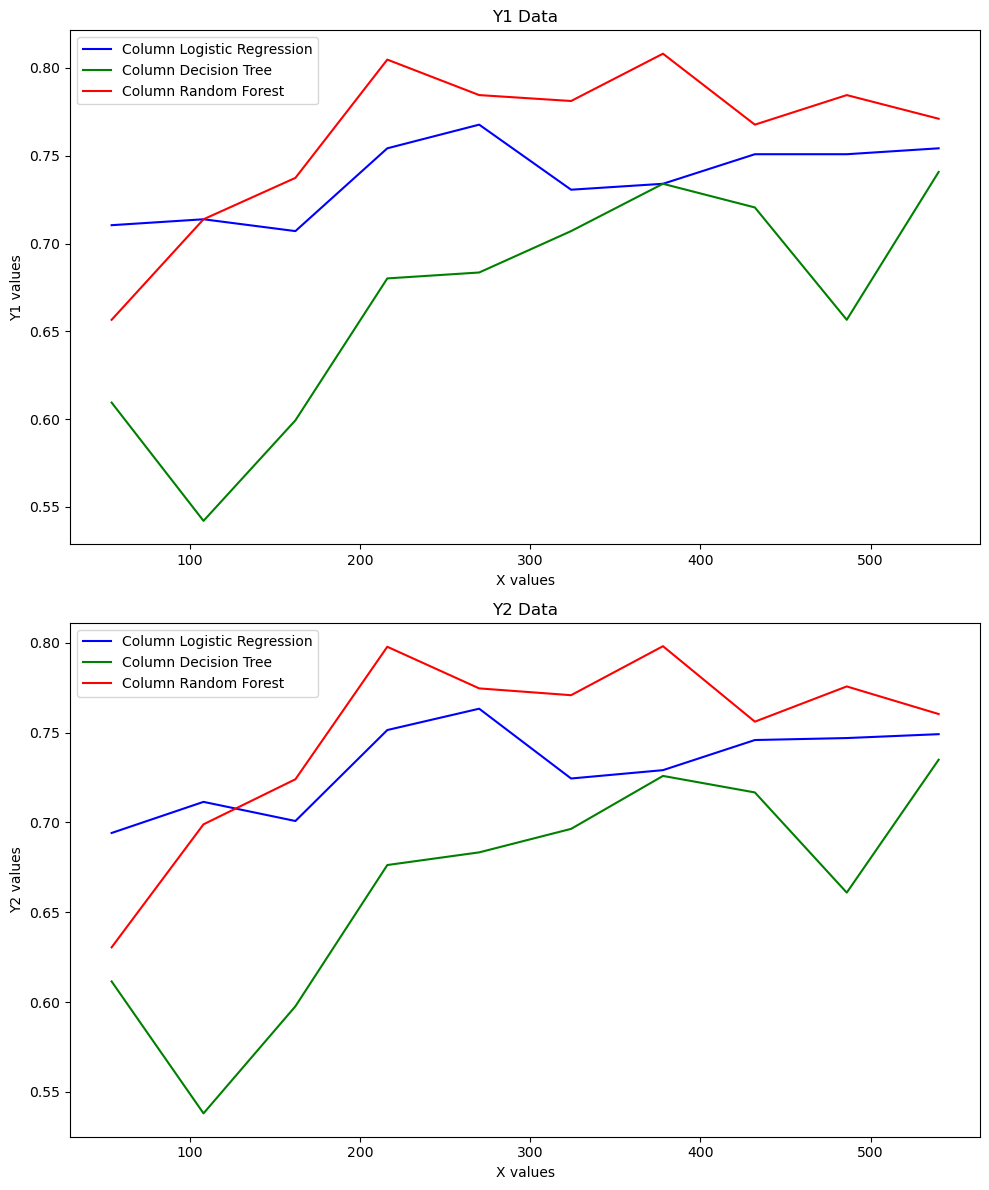

In [101]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))
colors = ['blue', 'green', 'red']  # lr, dt, rfc
names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
for i in range(3):
    ax1.plot(x, acc[:, i], color=colors[i], label=f'Column {names[i]}')
ax1.set_title('Y1 Data')
ax1.set_xlabel('X values')
ax1.set_ylabel('Y1 values')
ax1.legend()

# Plot for Y2
for i in range(3):
    ax2.plot(x, f1[:, i], color=colors[i], label=f'Column {names[i]}')
ax2.set_title('Y2 Data')
ax2.set_xlabel('X values')
ax2.set_ylabel('Y2 values')
ax2.legend()

# Adjust layout and display the plot
plt.tight_layout()
plt.show()